In [1]:
import pandas as pd
import glob
import csky as cy
from csky.utils import Arrays
import matplotlib.pyplot as plt
import histlite as hl
from pathlib import Path
import math
import re
import json
import os
import numpy as np
import sys
sys.path.append(os.path.abspath("../../../")) 
from matplotlib.ticker import LogLocator, NullFormatter
from kingmaker_fork.kingmaker.wrapper import KingSpatialLikelihood
from kingmaker_fork.likelihood_analysis.utils.trial_runner_config_loading import restore_king_trial_runner
from kingmaker_fork.likelihood_analysis.utils.parallel_king_trials import get_many_fits_from_trials
from kingmaker_fork.likelihood_analysis.analysis_helpers.to_jsonable import to_jsonable


from csky_gfu_tests.custom_gfu_specs import GFUDataSpecs as custom_gfu

In [2]:
timer = cy.timing.Timer()
time = timer.time

## Load cached Analysis

In [3]:
repo_cache = cy.utils.ensure_dir('/data/user/fkrafft/csky_repo')
repo = cy.selections.Repository(
    local_root= repo_cache,
    remote_root= '/data/ana/PointSource/GFU/online_v001-p10')

ana_dir = cy.utils.ensure_dir('/data/user/fkrafft/csky_gfu_tests')
with time('ana setup (from cache-to-disk)'):
    ana = cy.get_analysis(repo, 'version-001-p09' , custom_gfu.gfu_19_to_23, dir = ana_dir)

Setting up Analysis for:
GFU_2019_2023
Setting up GFU_2019_2023...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2023_MC.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2019_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2020_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2021_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2022_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2019_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2020_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2021_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2022_data.npy ...
Energy PDF Ratio Model...
  * gamma = 4.0000 ...
Signal Acceptance Model...
  * gamma = 4.0000 ...
not applying any masking
Done.

0:01:

## Load Background Trials

In [4]:
file_identifier = 'min_count_150_angErr12'
parent = '/data/user/fkrafft/csky_king_tests/'
input_dir = os.path.join(parent, f"{file_identifier}")
plot_dir = os.path.join(parent, f"{file_identifier}/plots")
target_N = 1000
sens_calc = True

In [5]:
m = re.match(r"min_count_(\d+)_angErr(\d+)", file_identifier)

min_count = int(m.group(1))
ang_err = int(m.group(2))

In [6]:

os.makedirs(plot_dir, exist_ok=True)

files = glob.glob(os.path.join(input_dir, "*.npy"))


In [ ]:
plotting = False
data_dict = {}

for f in files:

    basename = os.path.basename(f)

    match = re.search(
        r"sindec_([-+]?\d*\.?\d+).*?N_(\d+)",
        basename
    )

    if not match:
        continue

    sin_dec = float(match.group(1))
    N = int(match.group(2))

    # skip files with wrong N
    if N != target_N:
        continue
    

    sin_dec = float(match.group(1))
    src = cy.sources(0, np.arcsin(sin_dec), deg = False)
    tr, _, _, _ = restore_king_trial_runner(
        config_path=  os.path.join(input_dir, f"king_trial_runner_config_sindec_{sin_dec}_{file_identifier}.pkl"),
        ana = ana
        )
    arr = np.load(f)

    df = pd.DataFrame(arr)          # optional
    cached_trials = cy.utils.Arrays(arr)
    #apply fits
    bg = cy.dists.Chi2TSD(cached_trials)

    data_dict[sin_dec] = {
        "df": df,
        "cached_trials": cached_trials,
        "bg": bg,
        "tr": tr
    }
    if np.sum(cached_trials["ts"] > 0) == 0:
        continue
    if plotting: 
        fig, ax = plt.subplots()

        h = bg.get_hist(bins= 50)
        hl.plot1d(
            ax,
            h,
            crosses=True,
            label=f"{bg.n_total} bg trials"
        )

        x = h.centers[0]
        norm = h.integrate().values
        ax.grid(which = 'both', alpha = 0.5)
        ax.semilogy(
            x,
            norm * bg.pdf(x),
            lw=1,
            ls="--",
            color = 'red',
            label=rf"$\chi^2[{bg.ndof:.2f}\mathrm{{dof}},\ \eta={bg.eta:.3f}]$"
        )
        ax.axvline(bg.median(), color = 'black', linestyle = 'dashed', label = f'median of TS dist. ({bg.median():.2f})')
        ax.set_xlabel("TS")
        ax.set_ylabel("number of trials")
        ax.set_title("$\sin{\delta}$" + f" = {sin_dec:.2f}")
        ax.legend()
        plt.tight_layout()

        outpath = os.path.join(plot_dir, f"bkg_trials_sin_dec_{sin_dec:.2f}.png")
        fig.savefig(outpath, dpi=200)
        plt.show()
        plt.close(fig)

print(f"Saved plots to: {plot_dir}")

<>:70: SyntaxWarning: invalid escape sequence '\s'
<>:70: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2008778/2038659471.py:70: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title("$\sin{\delta}$" + f" = {sin_dec:.2f}")


NOTE: Using cached King parameters...
NOTE: Using cached King parameters...
NOTE: Using cached King parameters...
NOTE: Using cached King parameters...
NOTE: Using cached King parameters...
NOTE: Using cached King parameters...
NOTE: Using cached King parameters...
NOTE: Using cached King parameters...
Saved plots to: /data/user/fkrafft/csky_king_tests/min_count_150_angErr12/plots


In [8]:
for sin_dec, data in data_dict.items():
    print(f"{sin_dec}:\t {data['bg']}")

0.4:	 Chi2TSD(1000 trials, eta=0.643, ndof=1.204, median=0.156 (from fit 0.168))
-0.15:	 Chi2TSD(1000 trials, eta=0.910, ndof=1.798, median=2.261 (from fit 2.021))
-0.3:	 Chi2TSD(1000 trials, eta=0.496, ndof=1.041, median=0.000 (from fit 0.000))
-0.1:	 Chi2TSD(1000 trials, eta=1.000, ndof=8.461, median=14.095 (from fit 13.964))
-0.05:	 Chi2TSD(1000 trials, eta=0.977, ndof=1.901, median=3.590 (from fit 3.341))
-0.5:	 Chi2TSD(1000 trials, eta=0.509, ndof=1.225, median=0.001 (from fit 0.002))
0.2:	 Chi2TSD(1000 trials, eta=0.616, ndof=1.097, median=0.089 (from fit 0.097))
0.0:	 Chi2TSD(1000 trials, eta=0.909, ndof=1.695, median=2.112 (from fit 1.892))


<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2008778/2962883655.py:19: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title("$\chi^2$ fits for different $\sin{\delta}$")
/tmp/ipykernel_2008778/2962883655.py:20: SyntaxWarning: invalid escape sequence '\s'
  ax.legend(title="$\sin{\delta}$", ncol=2, fontsize=8)


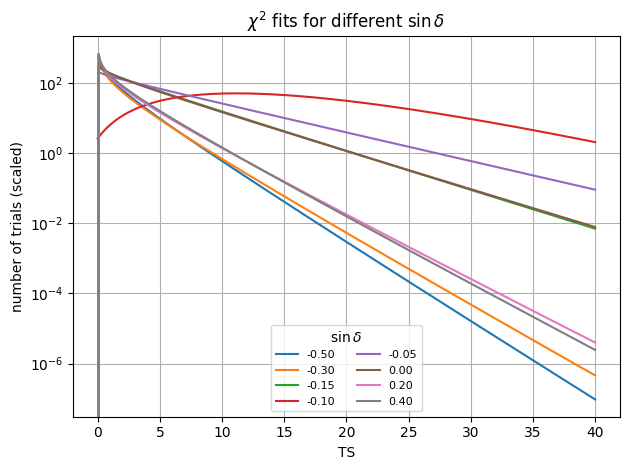

log


In [9]:
fig, ax = plt.subplots()

x = np.linspace(0, 40, 500)

for sin_dec, d in sorted(data_dict.items()):
    bg = d["bg"]

    # normalize like before
    norm = bg.n_total  # or use consistent normalization if preferred

    ax.semilogy(
        x,
        norm * bg.pdf(x),
        label=f"{sin_dec:.2f}"
    )

ax.set_xlabel("TS")
ax.set_ylabel("number of trials (scaled)")
ax.set_title("$\chi^2$ fits for different $\sin{\delta}$")
ax.legend(title="$\sin{\delta}$", ncol=2, fontsize=8)
ax.set_yscale("log")

# Major ticks (10^n)
ax.yaxis.set_major_locator(LogLocator(base=10))

# Minor ticks (2–9 within each decade)
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))

# Grid styling
ax.grid(which="major", linestyle="-", linewidth=0.8)
ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "summary_chi2.png"), dpi=200)
plt.show()
plt.close(fig)
print(ax.get_yscale())

## Estimate Sensitivity + Discovery Potential

In [10]:
if not sens_calc: 
    for sin_dec, d in sorted(data_dict.items()):
        trial_runner: cy.trial.TrialRunner = d["tr"]
        bkg = d["bg"]
        with time('ps sensitivity'):
            print(f'Estimating sensitivity for sin(dec) = {sin_dec}')
            sens = trial_runner.find_n_sig(
                # ts, threshold
                bkg.median(), # p = 50%
                # beta, fraction of trials which should exceed the threshold
                0.9, # beta = 90%
                # n_inj step size for initial scan
                n_sig_step=1,
                # this many trials at a time
                batch_size=500,
                # tolerance, as estimated relative error
                tol=.05,
                mp_cpus = 32
            )
            d["sens"] = sens
    sens_dict = {k: v["sens"] for k, v in data_dict.items()}
    json_sens_dict = to_jsonable(sens_dict)
    with open(os.path.join(plot_dir, 'king_sensitivity.json'), "w") as f:
        json.dump(json_sens_dict, f)

In [11]:
if not sens_calc:
    with open(os.path.join(plot_dir, 'king_sensitivity.json')) as f:
        json_sens_dict = json.load(f, parse_int = float)
        json_sens_dict = {float(k): v for k, v in json_sens_dict.items()}
else: 
    input_dir = Path(input_dir)

    for file in input_dir.glob("TEST_king_sens_*.json"):

        with open(file) as f:
            sens_data = json.load(f)

        # extract sin(dec) from filename
        # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
        name = file.stem

        sindec_str = name.split("sindec_")[1].split("_N_")[0]
        sin_dec = float(sindec_str)

        # store inside your existing data object
        if sin_dec in data_dict:
            data_dict[sin_dec]["sens"] = sens_data
        else:
            print(f"WARNING: sin_dec={sin_dec} not found in data_dict")

In [12]:
""" with open(os.path.join(plot_dir, 'king_sensitivity.json')) as f:
    json_sens_dict = json.load(f, parse_int = float)
    json_sens_dict = {float(k): v for k, v in json_sens_dict.items()}
for k, v in json_sens_dict.items():
    data_dict[k]["sens"] = v """

' with open(os.path.join(plot_dir, \'king_sensitivity.json\')) as f:\n    json_sens_dict = json.load(f, parse_int = float)\n    json_sens_dict = {float(k): v for k, v in json_sens_dict.items()}\nfor k, v in json_sens_dict.items():\n    data_dict[k]["sens"] = v '

In [13]:
with open(os.path.join('/data/user/fkrafft/csky_gfu_tests/rayleigh_benchmark_100k_19_to_23/plots', 'sensitivity.json')) as f:
    rayleigh_sens_dict = json.load(f, parse_int = float)
    rayleigh_sens_dict = {float(k): v for k, v in rayleigh_sens_dict.items()}

In [14]:
rayleigh_sens_dict.keys()

dict_keys([0.0, -0.15, 0.4, -0.1, -0.5, -0.05, -0.3, 0.2, -0.2])

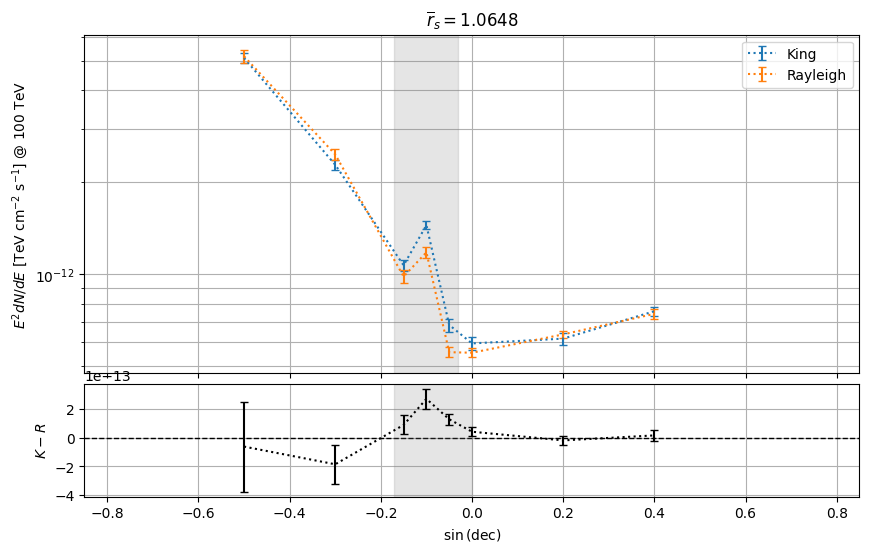

In [15]:
x = sorted(data_dict.keys())
#x = [0.4, 0.2, -0.5]

y = []
yerr = []
rayleigh_y = []
rayleigh_yerr = []

for k in x:
    d = data_dict[k]["sens"]
    tr = data_dict[k]["tr"]
    sens = d["n_sig"]

    rayleigh_d = rayleigh_sens_dict[k]
    rayleigh_sens = rayleigh_d["n_sig"]

    # percent → absolute error
    n_err = sens * d["n_sig_error"]
    rayleigh_n_err = rayleigh_sens * rayleigh_d["n_sig_error"]

    # central value
    flux = tr.to_E2dNdE(sens, E0=100, unit=1e3)
    rayleigh_flux = tr.to_E2dNdE(rayleigh_sens, E0=100, unit=1e3)

    # propagated error
    flux_err = tr.to_E2dNdE(sens + n_err, E0=100, unit=1e3) - flux
    rayleigh_flux_err = (
        tr.to_E2dNdE(rayleigh_sens + rayleigh_n_err, E0=100, unit=1e3)
        - rayleigh_flux
    )

    y.append(flux)
    yerr.append(flux_err)

    rayleigh_y.append(rayleigh_flux)
    rayleigh_yerr.append(rayleigh_flux_err)

# --- arrays ---
x = np.asarray(x)
y = np.asarray(y)
yerr = np.asarray(yerr)

rayleigh_y = np.asarray(rayleigh_y)
rayleigh_yerr = np.asarray(rayleigh_yerr)

#total score metric:
llh_score = np.mean(y/rayleigh_y)

# relative difference
absdiff = (y - rayleigh_y)

# error propagation
absdiff_err = np.sqrt(yerr**2 + rayleigh_yerr**2)

# --- plotting ---
fig, (ax, ax_diff) = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)
ax.set_title( r"$\overline{r}_s =$"+ str(llh_score.round(4)))
# top panel
ax.set_yscale("log")

ax.axvspan(-0.17, -0.03, color="grey", alpha=0.2, zorder=2)
ax.errorbar(
    x,
    y,
    yerr=yerr,
    ls = 'dotted',
    marker = '',
    capsize=3,
    zorder=3,
    label="King",
)

ax.errorbar(
    x,
    rayleigh_y,
    yerr=rayleigh_yerr,
    ls="dotted",
    capsize=3,
    zorder=3,
    label="Rayleigh",
)

ax.legend()

ax.set_xlim(-0.85, 0.85)

ax.set_ylabel(r"$E^2 dN/dE$ [TeV cm$^{-2}$ s$^{-1}$] @ 100 TeV")
ax.grid(which="both", zorder=1)

# bottom panel
#ax_diff.set_yscale('log')
ax_diff.axhline(0, color="black", lw=1, ls="--")

ax_diff.axvspan(-0.17, -0.00, color="grey", alpha=0.2, zorder=2)

ax_diff.errorbar(
    x,
    absdiff,
    yerr=absdiff_err,
    ls="dotted",
    capsize=3,
    zorder=3,
    color = 'black',
    
)

ax_diff.set_xlabel(r"$\sin{(\mathrm{dec})}$")
ax_diff.set_ylabel(r"$K - R$")
ax_diff.grid(which="both", zorder=1)

outpath = os.path.join(plot_dir, "sensitivity_flux_summary.png")

plt.savefig(outpath, dpi=200, bbox_inches="tight")
plt.show()

In [16]:
print(y)
print(rayleigh_y)

[5.11160676e-12 2.28369756e-12 1.07030305e-12 1.44880045e-12
 6.82720587e-13 5.93813314e-13 6.15651379e-13 7.56951502e-13]
[5.17450238e-12 2.46952689e-12 9.82972168e-13 1.18028761e-12
 5.55812325e-13 5.53529166e-13 6.35551279e-13 7.42230845e-13]


In [17]:
#save total score to csv
csv_file = os.path.join(parent, 'llh_score_summary.csv')

# new row:
entry = {
    'min_counts' : min_count,
    ''
    'ang_err'   : ang_err, 
    'llh_score' : llh_score
}
if Path(csv_file).exists():
    df = pd.read_csv(csv_file)
else:
    df = pd.DataFrame(columns=["min_counts", "ang_err", "llh_score"])

# Append row
df.loc[len(df)] = entry

df.to_csv(csv_file, index=False)

In [18]:
with open(os.path.join('/data/user/fkrafft/csky_gfu_tests/rayleigh_benchmark_100k_19_to_23/plots', 'discovery_potential.json')) as f:
    rayleigh_disc_dict = json.load(f, parse_int = float)
    rayleigh_disc_dict = {float(k): v for k, v in rayleigh_disc_dict.items()}

In [19]:
if not sens_calc:
    for sin_dec, d in sorted(data_dict.items()):
        trial_runner: cy.trial.TrialRunner = d["tr"]
        bkg = d["bg"]
        with time('ps discovery potential'):
            print(f'Estimating discovery potential for sin(dec) = {sin_dec}')
            disc = trial_runner.find_n_sig(
            bkg.isf_nsigma(5), # p = 5 sigma
            0.5, # beta = 50%
            n_sig_step=5, 
            batch_size=500, 
            tol=.05)
            d["disc"] = disc
    disc_dict = {k: v["disc"] for k, v in data_dict.items()}
    json_disc_dict = to_jsonable(disc_dict)
    with open(os.path.join(plot_dir, 'discovery_potential.json'), "w") as f:
        json.dump(json_disc_dict, f)

In [20]:
if not sens_calc:
    with open(os.path.join(plot_dir, 'discovery_potential.json')) as f:
        json_disc_dict = json.load(f, parse_int = float)
        json_disc_dict = {float(k): v for k, v in json_disc_dict.items()}
else: 
    input_dir = Path(input_dir)

    for file in input_dir.glob("TEST_king_disc_*.json"):

        with open(file) as f:
            disc_data = json.load(f)

        # extract sin(dec) from filename
        # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
        name = file.stem

        sindec_str = name.split("sindec_")[1].split("_N_")[0]
        sin_dec = float(sindec_str)

        # store inside your existing data object
        if sin_dec in data_dict:
            data_dict[sin_dec]["disc"] = disc_data
        else:
            print(f"WARNING: sin_dec={sin_dec} not found in data_dict")

In [21]:
rayleigh_disc_dict.keys()

dict_keys([0.0, -0.15, 0.4, -0.1, -0.5, -0.05, -0.3, 0.2, -0.2])

### 3-$\sigma$ Discovery Potential

In [32]:
if not sens_calc:
    for sin_dec, d in sorted(data_dict.items()):
        trial_runner: cy.trial.TrialRunner = d["tr"]
        bkg = d["bg"]
        with time('ps 3 sigma discovery potential'):
            print(f'Estimating discovery potential for sin(dec) = {sin_dec}')
            disc = trial_runner.find_n_sig(
            bkg.isf_nsigma(3), # p = 5 sigma
            0.5, # beta = 50%
            n_sig_step=5, 
            batch_size=500, 
            tol=.05,
            mp_cpus = 32)
            d["3sig_disc"] = disc
    disc_dict_3_sig = {k: v["3sig_disc"] for k, v in data_dict.items()}
    json_disc_dict = to_jsonable(disc_dict_3_sig)
    with open(os.path.join(plot_dir, 'discovery_potential_3sig.json'), "w") as f:
        json.dump(json_disc_dict, f)
        
    with open(os.path.join(plot_dir, 'discovery_potential_3sig.json')) as f:
        json_3_sig_disc_dict = json.load(f, parse_int = float)
        json_3_sig_disc_dict = {float(k): v for k, v in json_3_sig_disc_dict.items()}
    
else:
    input_dir = Path(plot_dir)

    for file in input_dir.glob("TEST_king_3sig_disc*.json"):

        with open(file) as f:
            disc_3sig_data = json.load(f)

        # extract sin(dec) from filename
        # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
        name = file.stem

        sindec_str = name.split("sindec_")[1].split("_N_")[0]
        sin_dec = float(sindec_str)

        # store inside your existing data object
        if sin_dec in data_dict:
            data_dict[sin_dec]["3sig_disc"] = disc_3sig_data
        else:
            print(f"WARNING: sin_dec={sin_dec} not found in data_dict")

In [35]:
with open(os.path.join(plot_dir, 'discovery_potential_3sig.json')) as f:
    json_3_sig_disc_dict = json.load(f, parse_int = float)
    json_3_sig_disc_dict = {float(k): v for k, v in json_3_sig_disc_dict.items()}
json_3_sig_disc_dict

for sin_dec, data in json_3_sig_disc_dict.items():
    data_dict[sin_dec]["3sig_disc"] = data

In [36]:
with open(os.path.join('/data/user/fkrafft/csky_gfu_tests/rayleigh_benchmark_100k_19_to_23/plots', 'discovery_potential_3sig.json')) as f:
    rayleigh_disc_3sig_dict = json.load(f, parse_int = float)
    rayleigh_disc_3sig_dict = {float(k): v for k, v in rayleigh_disc_3sig_dict.items()}
rayleigh_disc3_y = []
rayleigh_disc3_yerr = []

for k in x:
    tr = data_dict[k]["tr"]

    rayleigh_disc3_d = rayleigh_disc_3sig_dict[k]
    rayleigh_disc3_nsig = rayleigh_disc3_d["n_sig"]
    rayleigh_disc3_nerr = rayleigh_disc3_nsig * rayleigh_disc3_d["n_sig_error"]

    rayleigh_disc3_flux = tr.to_E2dNdE(rayleigh_disc3_nsig, E0=100, unit=1e3)

    rayleigh_disc3_flux_err = (
        tr.to_E2dNdE(rayleigh_disc3_nsig + rayleigh_disc3_nerr, E0=100, unit=1e3)
        - rayleigh_disc3_flux
    )

    rayleigh_disc3_y.append(rayleigh_disc3_flux)
    rayleigh_disc3_yerr.append(rayleigh_disc3_flux_err)

rayleigh_disc3_y = np.asarray(rayleigh_disc3_y)
rayleigh_disc3_yerr = np.asarray(rayleigh_disc3_yerr)

In [37]:
x = [-0.5, -0.3, -0.15, -0.1, 0.0, 0.2, 0.4]

In [38]:

disc3_y = []
disc3_yerr = []

for k in x:
    d = data_dict[k]["sens"]
    tr = data_dict[k]["tr"]

    disc3_nsig = data_dict[k]["3sig_disc"]['n_sig']

    disc3_n_err = disc3_nsig * data_dict[k]["3sig_disc"]["n_sig_error"]

    disc3_flux = tr.to_E2dNdE(disc3_nsig, E0=100, unit=1e3)
    disc3_flux_err = (
        tr.to_E2dNdE(disc3_nsig + disc3_n_err, E0=100, unit=1e3)
        - disc3_flux
    )

    disc3_y.append(disc3_flux)
    disc3_yerr.append(disc3_flux_err)

disc3_y = np.asarray(disc3_y)
disc3_yerr = np.asarray(disc3_yerr)

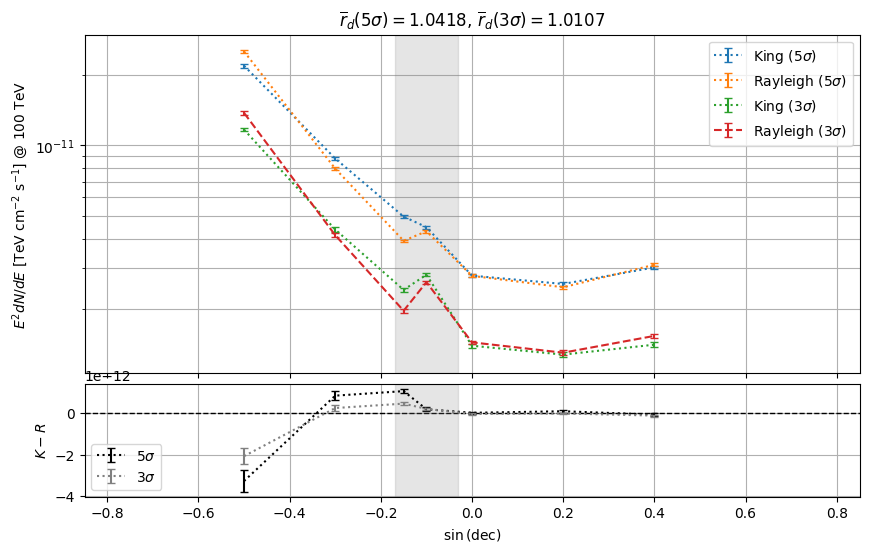

In [40]:


y = []
yerr = []
rayleigh_y = []
rayleigh_yerr = []

for k in x:
    d = data_dict[k]["disc"]
    tr = data_dict[k]["tr"]

    disc = d["n_sig"]

    rayleigh_d = rayleigh_disc_dict[k]
    rayleigh_disc = rayleigh_d["n_sig"]

    # percent -> absolute error
    disc_err = disc * d["n_sig_error"]
    rayleigh_disc_err = rayleigh_disc * rayleigh_d["n_sig_error"]

    # central value
    flux = tr.to_E2dNdE(disc, E0=100, unit=1e3)
    rayleigh_flux = tr.to_E2dNdE(rayleigh_disc, E0=100, unit=1e3)

    # propagated error
    flux_err = tr.to_E2dNdE(disc + disc_err, E0=100, unit=1e3) - flux
    rayleigh_flux_err = (
        tr.to_E2dNdE(rayleigh_disc + rayleigh_disc_err, E0=100, unit=1e3)
        - rayleigh_flux
    )

    y.append(flux)
    yerr.append(flux_err)

    rayleigh_y.append(rayleigh_flux)
    rayleigh_yerr.append(rayleigh_flux_err)

# --- arrays ---
x = np.asarray(x)
y = np.asarray(y)
yerr = np.asarray(yerr)

rayleigh_y = np.asarray(rayleigh_y)
rayleigh_yerr = np.asarray(rayleigh_yerr)

# total score metric
llh_score = np.mean(y / rayleigh_y)
llh_score_3_sig = np.mean(disc3_y/rayleigh_disc3_y)

# absolute difference
absdiff = y - rayleigh_y

# error propagation
absdiff_err= np.sqrt(yerr**2 + rayleigh_yerr**2)

# absolute difference (3 sig)
absdiff_3sig = disc3_y - rayleigh_disc3_y


# error propagation (3 sig)
absdiff_err_3sig = np.sqrt(disc3_yerr**2 + rayleigh_disc3_yerr**2)


# --- plotting ---
fig, (ax, ax_diff) = plt.subplots(
    2,
    1,
    figsize=(10, 6),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
)

ax.set_title(r"$\overline{r}_d(5\sigma) =$" + str(llh_score.round(4)) + r", $\overline{r}_d(3\sigma) =$" +str(llh_score_3_sig.round(4)))

# top panel
ax.set_yscale("log")

ax.axvspan(-0.17, -0.03, color="grey", alpha=0.2, zorder=2)

ax.errorbar(
    x,
    y,
    yerr=yerr,
    ls="dotted",
    marker="",
    capsize=3,
    zorder=3,
    label=r"King (5$\sigma$)",
)

ax.errorbar(
    x,
    rayleigh_y,
    yerr=rayleigh_yerr,
    ls="dotted",
    marker="",
    capsize=3,
    zorder=3,
    label=r"Rayleigh (5$\sigma$)",
)
ax.errorbar(
    x,
    disc3_y,
    yerr=disc3_yerr,
    ls="dotted",
    capsize=3,
    zorder=3,
    label=r"King (3$\sigma$)",
)
ax.errorbar(
    x,
    rayleigh_disc3_y,
    yerr=rayleigh_disc3_yerr,
    ls="--",
    capsize=3,
    zorder=3,
    label=r"Rayleigh (3$\sigma$)",
)

ax.legend()
ax.set_xlim(-0.85, 0.85)
ax.set_ylabel(r"$E^2 dN/dE$ [TeV cm$^{-2}$ s$^{-1}$] @ 100 TeV")
ax.grid(which="both", zorder=1)

# bottom panel
ax_diff.axhline(0, color="black", lw=1, ls="--")
ax_diff.axvspan(-0.17, -0.03, color="grey", alpha=0.2, zorder=2)

ax_diff.errorbar(
    x,
    absdiff,
    yerr=absdiff_err,
    ls="dotted",
    capsize=3,
    zorder=3,
    color="black",
    label = r"$5 \sigma$"
)
ax_diff.errorbar(
    x,
    absdiff_3sig,
    yerr=absdiff_err_3sig,
    ls="dotted",
    capsize=3,
    zorder=3,
    color="grey",
    label = r"$3 \sigma$"
)

ax_diff.set_xlabel(r"$\sin{(\mathrm{dec})}$")
ax_diff.set_ylabel(r"$K - R$")
ax_diff.legend()
ax_diff.grid(which="both", zorder=1)

# Careful: absdiff can be negative, so log scale may break.
# Use linear scale unless you are sure all differences are positive.
# ax_diff.set_yscale("log")

outpath = os.path.join(plot_dir, "discovery_potential_flux_summary.png")

plt.savefig(outpath, dpi=200, bbox_inches="tight")
plt.show()

## 3. Test for Bias

One powerful test of analysis readiness is to demonstrate that we can properly fit the parameters of an injected signal. For this we start by getting some batches of signal trials:

In [ ]:
n_sigs = np.r_[:101:10]
with time('ps fit bias trials'):
    for sin_dec, data in data_dict.items():
        trials = [get_many_fits_from_trials(tr = data["tr"],
                                            n_trials= 100, 
                                            n_sig=n_sig, 
                                            logging=True, 
                                            mp_cpus = 32,
                                            seed=int(n_sig)) for n_sig in n_sigs]
        
        #We add the true number of events injected for bookkeeping convenience:
        for (n_sig, t) in zip(n_sigs, trials):
            t['ntrue'] = np.repeat(n_sig, len(t))

        #Concatenate the trial batches:
        allt = cy.utils.Arrays.concatenate(trials)
        data_dict[sin_dec]['allt'] = allt

Plots:

In [ ]:
for sin_dec, data in data_dict.items():
    tr = data['tr']
    allt = data['allt']
    
    fig, axs = plt.subplots(1, 2, figsize=(6,3))

    dns = np.mean(np.diff(n_sigs))
    ns_bins = np.r_[n_sigs - 0.5*dns, n_sigs[-1] + 0.5*dns]
    expect_kw = dict(color='C0', ls='--', lw=1, zorder=-10)
    expect_gamma = tr.sig_injs[0].flux[0].gamma

    ax = axs[0]
    h = hl.hist((allt.ntrue, allt.ns), bins=(ns_bins, 100))
    hl.plot1d(ax, h.contain_project(1),errorbands=True, drawstyle='default')

    lim = ns_bins[[0, -1]]
    ax.set_xlim(ax.set_ylim(lim))
    ax.plot(lim, lim, **expect_kw)
    ax.set_aspect('equal')


    ax = axs[1]
    h = hl.hist((allt.ntrue, allt.gamma), bins=(ns_bins, 100))
    hl.plot1d(ax, h.contain_project(1),errorbands=True, drawstyle='default')
    ax.axhline(expect_gamma, **expect_kw)
    ax.set_xlim(axs[0].get_xlim())

    for ax in axs:
        ax.set_xlabel(r'$n_\text{inj}$')
        ax.grid()
    axs[0].set_ylabel(r'$n_s$')
    axs[1].set_ylabel(r'$\gamma$')
    plt.suptitle(f'King: PS for sin(dec) = {sin_dec}')
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"ps_king_sindec{sin_dec}.pdf"))

In [ ]:
for sin_dec, data in data_dict.items():

    tr = data["tr"]
    allt = data["allt"]

    dns = np.mean(np.diff(n_sigs))
    ns_bins = np.r_[n_sigs - 0.5*dns, n_sigs[-1] + 0.5*dns]
    expect_gamma = tr.sig_injs[0].flux[0].gamma

    out = os.path.join(plot_dir, f"ps_king_sindec{sin_dec}.npz")

    np.savez(
        out,
        sin_dec=sin_dec,
        ntrue=np.asarray(allt.ntrue),
        ns=np.asarray(allt.ns),
        gamma=np.asarray(allt.gamma),
        n_sigs=np.asarray(n_sigs),
        ns_bins=np.asarray(ns_bins),
        expect_gamma=expect_gamma,
    )

load PS from rayleigh, king for comparison

In [ ]:
king_dir = Path(plot_dir)

king_files = sorted(king_dir.glob("ps_king_sindec*.npz"))

ps_king_data = {}

for f in king_files:
    d = np.load(f)

    sin_dec = float(d["sin_dec"])

    ps_king_data[sin_dec] = {
        "ntrue": d["ntrue"],
        "ns": d["ns"],
        "gamma": d["gamma"],
        "ns_bins": d["ns_bins"],
        "expect_gamma": float(d["expect_gamma"]),
    }

print(ps_king_data.keys())

In [ ]:

rayleigh_dir = Path("/data/user/fkrafft/csky_gfu_tests/trials_100k_post2018/plots")

rayleigh_files = sorted(rayleigh_dir.glob("ps_rayleigh_sindec*.npz"))

ps_rayleigh_data = {}

for f in rayleigh_files:
    d = np.load(f)

    sin_dec = float(d["sin_dec"])

    ps_rayleigh_data[sin_dec] = {
        "ntrue": d["ntrue"],
        "ns": d["ns"],
        "gamma": d["gamma"],
        "ns_bins": d["ns_bins"],
        "expect_gamma": float(d["expect_gamma"]),
    }

print(ps_rayleigh_data.keys())

In [ ]:
def plot_king_vs_rayleigh(ps_king_data, ps_rayleigh_data, plot_dir=None):
    matching_sindecs = sorted(set(ps_king_data) & set(ps_rayleigh_data))

    for sin_dec in matching_sindecs:
        king = ps_king_data[sin_dec]
        ray = ps_rayleigh_data[sin_dec]

        fig, axs = plt.subplots(
            2, 2,
            figsize=(7, 5),
            sharex="col",
            gridspec_kw={"height_ratios": [3, 1]},
        )

        # ---------- n_s plot ----------
        ax = axs[0, 0]
        rax = axs[1, 0]

        h_king = hl.hist(
            (king["ntrue"], king["ns"]),
            bins=(king["ns_bins"], 100),
        ).contain_project(1)

        h_ray = hl.hist(
            (ray["ntrue"], ray["ns"]),
            bins=(ray["ns_bins"], 100),
        ).contain_project(1)

        hl.plot1d(ax, h_king, errorbands=True, drawstyle="default", label="King")
        hl.plot1d(ax, h_ray, errorbands=True, drawstyle="default", label="Rayleigh")

        x_ns = h_king.centers[0]

        # deviation from expectation: n_s = n_inj
        king_dev = h_king.values - x_ns
        ray_dev  = h_ray.values - x_ns

        # mean absolute deviation
        king_mean_dev = np.mean(np.abs(king_dev))
        ray_mean_dev  = np.mean(np.abs(ray_dev))

        rax.axhline(0, color="k", lw=1)
        rax.plot(
            x_ns,
            king_dev,
            drawstyle="steps-mid",
            label=f"King ⟨Δ⟩={king_mean_dev:.2f}",
        )
        rax.plot(
            x_ns,
            ray_dev,
            drawstyle="steps-mid",
            label=f"Rayleigh ⟨Δ⟩={ray_mean_dev:.2f}",
        )

        lim = king["ns_bins"][[0, -1]]
        ax.plot(lim, lim, color="grey", ls="--", lw=1, zorder=-10)

        ax.set_xlim(lim)
        ax.set_ylim(lim)
        ax.set_aspect("equal")

        ax.set_ylabel(r"$n_s$")
        rax.set_ylabel(r"$n_s - n_\mathrm{inj}$")
        rax.set_xlabel(r"$n_\text{inj}$")

        # ---------- gamma plot ----------
        ax = axs[0, 1]
        rax = axs[1, 1]

        h_king = hl.hist(
            (king["ntrue"], king["gamma"]),
            bins=(king["ns_bins"], 100),
        ).contain_project(1)

        h_ray = hl.hist(
            (ray["ntrue"], ray["gamma"]),
            bins=(ray["ns_bins"], 100),
        ).contain_project(1)

        hl.plot1d(ax, h_king, errorbands=True, drawstyle="default", label="King")
        hl.plot1d(ax, h_ray, errorbands=True, drawstyle="default", label="Rayleigh")

        x_gamma = h_king.centers[0]

        # reference line: gamma = expect_gamma
        gamma_ref = king["expect_gamma"]

        king_dev = h_king.values - gamma_ref
        ray_dev  = h_ray.values - gamma_ref

        # mean deviation
        king_mean_dev = np.mean(np.abs(king_dev))
        ray_mean_dev  = np.mean(np.abs(ray_dev))

        rax.axhline(0, color="k", lw=1)
        rax.plot(
            x_gamma,
            king_dev,
            drawstyle="steps-mid",
            label=f"King ⟨Δ⟩={king_mean_dev:.2f}",
        )
        rax.plot(
            x_gamma,
            ray_dev,
            drawstyle="steps-mid",
            label=f"Rayleigh ⟨Δ⟩={ray_mean_dev:.2f}",
        )

        ax.axhline(gamma_ref, color="grey", ls="--", lw=1, zorder=-10)
        ax.set_xlim(axs[0, 0].get_xlim())

        ax.set_ylabel(r"$\gamma$")
        rax.set_ylabel(r"$\gamma - \gamma_\mathrm{exp}$")
        rax.set_xlabel(r"$n_\text{inj}$")

        for ax in axs.flat:
            ax.grid()

        axs[0, 0].legend()
        axs[1, 0].legend()
        axs[1, 1].legend()

        fig.suptitle(f"PS comparison for sin(dec) = {sin_dec}")
        fig.tight_layout()

        if plot_dir is not None:
            fig.savefig(
                f"{plot_dir}/ps_king_vs_rayleigh_sindec{sin_dec}.pdf"
            )

        plt.show()

In [ ]:
plot_king_vs_rayleigh(ps_king_data, ps_rayleigh_data, plot_dir=plot_dir)